# Titre

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [30]:
data = pd.read_csv('lung_cancer_dataset.csv')
print(data.head())

  Patient_ID  Diagnosis_Year  ... Survival_Months Survived
0    LC-0001            2020  ...               4       No
1    LC-0002            2021  ...              76      Yes
2    LC-0003            2017  ...              69       No
3    LC-0004            2018  ...               9       No
4    LC-0005            2024  ...               5      Yes

[5 rows x 46 columns]


## Nettoyage du jeu de données avant l'analyse.

In [31]:
data = data.drop_duplicates().replace([np.inf, -np.inf], np.nan)

## Recuperation des data quantitative

In [32]:
quantitative_data = data.select_dtypes(include='number').copy()
quantitative_data = quantitative_data.dropna(axis=1, how='all')
quantitative_data = quantitative_data.fillna(quantitative_data.median())

## Standardisation des variables quantitatives.

In [33]:
x_scaled = StandardScaler().fit_transform(quantitative_data)

## Projection des individus sur les composantes

In [34]:
pca = PCA()
pca_res = pca.fit_transform(x_scaled)

## Tableau récapitulatif des valeurs propres et de leur contribution.

In [35]:
eig = pd.DataFrame({
	'Dimension': [f'Dim{x + 1}' for x in range(10)],
	'Valeur propre': pca.explained_variance_,
	'% valeur propre': np.round(pca.explained_variance_ratio_ * 100, 2),
	'% cum. val. propre': np.round(
		np.cumsum(pca.explained_variance_ratio_) * 100, 2
	)
})
print(eig)

  Dimension  Valeur propre  % valeur propre  % cum. val. propre
0      Dim1       3.257592            32.56               32.56
1      Dim2       1.518044            15.17               47.73
2      Dim3       1.040895            10.40               58.14
3      Dim4       1.018477            10.18               68.32
4      Dim5       0.972155             9.72               78.03
5      Dim6       0.965591             9.65               87.68
6      Dim7       0.669497             6.69               94.38
7      Dim8       0.308798             3.09               97.46
8      Dim9       0.185176             1.85               99.31
9     Dim10       0.068777             0.69              100.00


## Diagramme en bâtons des pourcentages de variance expliquée.

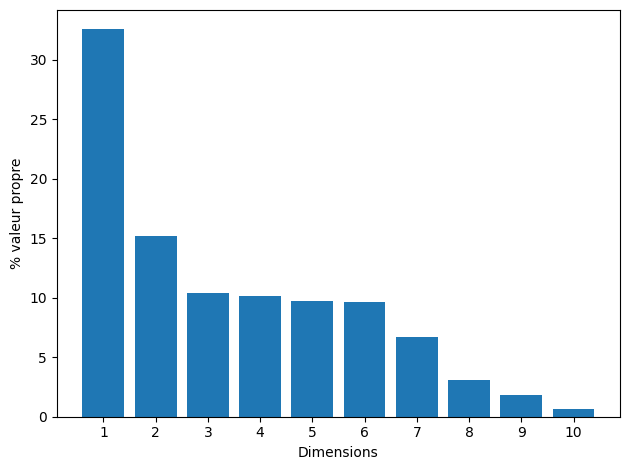

In [36]:
dimensions = range(1, len(pca.explained_variance_ratio_) + 1)
plt.bar(dimensions, pca.explained_variance_ratio_ * 100)
plt.xlabel('Dimensions')
plt.ylabel('% valeur propre')
plt.xticks(list(dimensions))
plt.tight_layout()
plt.show()

# Graphique des variables

Attention : pour des facilités d'affichage, les données sont centrées-réduites


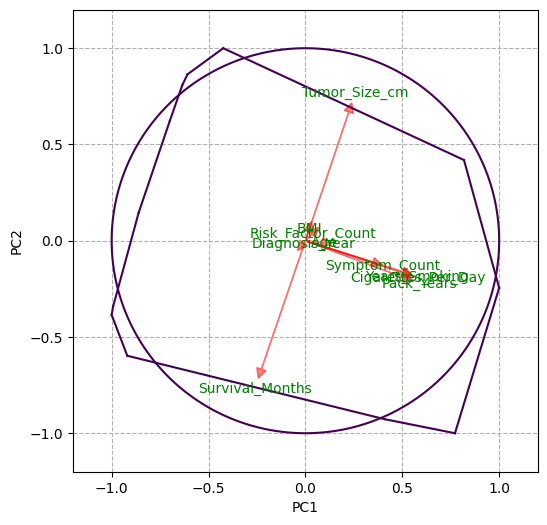

In [39]:
from biplot import biplot

biplot(
    score=pca_res[:, :2],
    coeff=pca.components_[:2, :].T,
    cat=None,
    density=False,
    coeff_labels=list(quantitative_data.columns),
)
plt.show()